<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/EDA/Edgar_Gelvis_Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>

<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 1: Análisis exploratorio de datos</header1></left>

# Estudio de Caso: [Nombre del estudio] (El título debe reflejar el problema, no solo el dataset. Evitar “Análisis de Penguins”.)

**Autor:**  **EDGAR FERNANDO GELVIS VEGA**

**Fecha:**  **Mayo 4 de 2026**

**Curso:**  **Estadistica para ciencia de Datos**

## Descripción general

En este estudio se realiza un análisis exploratorio de datos (EDA) utilizando el dataset *Palmer Penguins*, con el objetivo de identificar patrones, tendencias y relaciones entre variables que permitan responder a un problema planteado en contexto.

---

## Importación de librerias necesarias

In [12]:
#Para esta actividad se importarán las siguientes librerías:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#warnings
import warnings
warnings.filterwarnings("ignore")

## Cargar el Dataset

In [11]:
#Código para cargar el Dataset
#url = 'insertar url'

import kagglehub

# Download latest version
path = kagglehub.dataset_download("amulyas/penguin-size-dataset")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'penguin-size-dataset' dataset.
Path to dataset files: /kaggle/input/penguin-size-dataset


In [14]:
import os
# Verificar el contenido de la carpeta descargada
print("Contenido de la carpeta descargada:", os.listdir(path))

Contenido de la carpeta descargada: ['penguins_size.csv']


In [15]:
#Código para cargar el Dataset
#url = 'insertar url'

import kagglehub

# Download latest version
path = kagglehub.dataset_download("amulyas/penguin-size-dataset")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'penguin-size-dataset' dataset.
Path to dataset files: /kaggle/input/penguin-size-dataset


In [17]:
# Ruta del archivo CSV en el dataset descargado
file_path = os.path.join(path, "penguins_size.csv")

In [18]:
pd.read_csv(file_path)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


## Planteamiento del problema

Describe un problema claro, concreto y analizable a partir de los datos disponibles.

**Problema:**
[Escribe aquí el problema]

---

In [ ]:
#El problema debe ser evaluable con datos.

In [ ]:
#Código que responde a la descripción anterior

## Hipótesis o supuesto de investigación

Formula una hipótesis o supuesto que pueda explorarse mediante análisis descriptivo.

**Hipótesis:**
[Escribe aquí la hipótesis]

---

In [ ]:
# La hipótesis debe ser comprobable con patrones o relaciones observables, no causal.

In [ ]:
#Código que responde a la descripción anterior

## Justificación del estudio

Explica por qué es relevante analizar este problema. Puedes apoyarte en literatura o contexto aplicado.

---

### Referencias

Incluye al menos una referencia en formato APA que respalde la importancia del problema o el uso del dataset.

- Autor(es). (Año). Título. Fuente.

In [ ]:
# No es relleno: deben justificar por qué importa el análisis (biología, ciencia de datos, clasificación, etc.)

### Datos complementarios (opcional)

Describe si utilizaste fuentes adicionales y cómo aportaron al análisis.

- Fuente:
- Uso:
- Valor agregad

## Exploración inicial de los datos

Describe de forma general el dataset:

A continuación, se presenta la descripción general del conjunto de datos que su resumen esta en la Tabla 4

•	Número de observaciones: El dataset está compuesto por 344 filas.  

•	Variables disponibles: Se cuenta con un total de 7 variables para el análisis.

•	Presencia de valores nulos: Se identificaron 18 datos faltantes en el conjunto.

•	Tipos de variables: Técnicamente, el dataset contiene 3 variables de tipo categórico (object) y 4 de tipo numérico continuo (float64).


---

### Observaciones iniciales

Para iniciar el análisis del conjunto de datos Penguin Sizes (descargado de la plataforma Kaggle), se realizó una exploración general que arrojó los siguientes resultados estructurales:

Con la información de Tabla 1 y 4, el dataset está compuesto por 344 observaciones y 7 variables. Desde el punto de vista técnico, la información se clasifica en:

Desde el punto de vista técnico, la información contenida en el dataset se clasifica en dos grandes grupos. Por un lado, se identificaron cuatro atributos morfológicos de tipo numérico continuo (float64):

1. la longitud(culmen_length_mm)

2. la profundidad del culmen (culmen_depth_mm)

3. la longitud de las aletas (flipper_length_mm)

4. y la última es la masa corporal (body_mass_g)


Por otro lado, estos datos se complementan con tres variables cualitativas de tipo texto (object), correspondientes a:

1. la especie (species),

2. la ubicación geográfica o isla (island)

3. y por último  el sexo de los ejemplares (sex)

Finalmente, durante la inspección se identificaron 18 valores nulos en el conjunto, los cuales deberán ser procesados antes de avanzar con la fase de modelado o análisis estadístico.



In [61]:

file_path = os.path.join(path, "penguins_size.csv")

In [62]:
df=pd.read_csv(file_path)

In [63]:
df.info() #Tabla 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [64]:
df.isnull()   #Tabla 2

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


In [65]:
df.isnull().sum()  #Tabla 3

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [66]:

#Tabla 4
# Supongamos que tu DataFrame se llama 'df'
total_filas = len(df)
total_columnas = len(df.columns)

# 1. Suma de nulos por cada columna (genera una serie)
nulos_por_columna = df.isnull().sum()

# 2. Suma total de todos los nulos en el DataFrame completo
total_nulos_global = nulos_por_columna.sum()

# 3. Cálculo del porcentaje de nulos respecto al total de celdas del dataset
total_celdas = total_filas * total_columnas
porcentaje_global = (total_nulos_global / total_celdas) * 100

print(f"--- Resumen Global de Calidad de Datos ---")
print(f"Total de registros (filas): {total_filas}")
print(f"Total de variables (columnas): {total_columnas}")
print(f"Suma total de datos nulos detectados: {total_nulos_global}")
print(f"Impacto global de nulos en el dataset: {porcentaje_global:.2f}%")

# Opcional: Mostrar el detalle por columna para identificar dónde está el problema
print("\nDetalle de nulos por columna:")
print(nulos_por_columna)

--- Resumen Global de Calidad de Datos ---
Total de registros (filas): 344
Total de variables (columnas): 7
Suma total de datos nulos detectados: 18
Impacto global de nulos en el dataset: 0.75%

Detalle de nulos por columna:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


# Aquí empieza el pensamiento estadístico: calidad de datos, estructura, posibles sesgos.

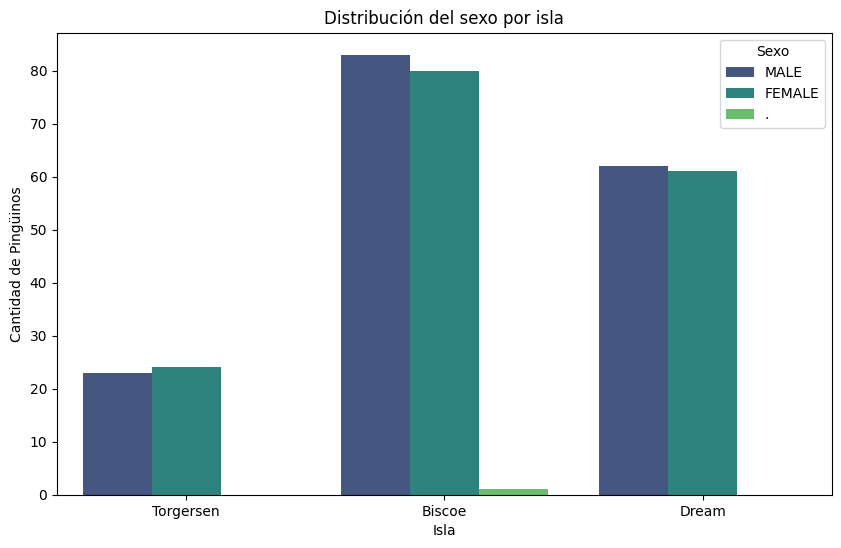

In [51]:
#Gráfica 1

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='island', hue='sex', palette='viridis')
plt.title('Distribución del sexo por isla')
plt.xlabel('Isla')
plt.ylabel('Cantidad de Pingüinos')
plt.legend(title='Sexo')
plt.show()

In [38]:
porcentaje_nulos = df['sex'].isnull().mean() * 10 #Anáslis 1
print(f"El porcentaje de datos nulos en 'sex' es: {porcentaje_nulos:.2f}%")

El porcentaje de datos nulos en 'sex' es: 0.29%


In [40]:
total_filas = len(df) #Anáslis 2
conteo_nulos = df['sex'].isnull().sum()
print(f"Detalle: {conteo_nulos} nulos de un total de {total_filas} registros.")

Detalle: 10 nulos de un total de 344 registros.


In [41]:
df.groupby('island')['sex'].apply(lambda x: x.isnull().mean() * 100) #Tabla 5

,sex
island,
Biscoe,2.380952
Dream,0.806452
Torgersen,9.615385


In [68]:
# Agregamos una columna de porcentaje de nulos a sex_summary
sex_summary['porcentaje_nulos'] = (sex_summary['null_data'] / sex_summary['total_data']) * 100

print("Comparativa de datos de 'sex' por isla (Total vs. Nulos con porcentaje)")
display(sex_summary)

Comparativa de datos de 'sex' por isla (Total vs. Nulos con porcentaje)


,island,total_data,null_data,porcentaje_nulos
0,Biscoe,168,4,2.380952
1,Dream,124,1,0.806452
2,Torgersen,52,5,9.615385


In [ ]:
#Después si se quiere filtras por las columnas de interés

### Selección de variables

Describe las variables que utilizarás en el análisis.

| Variable | Tipo (numérica/categórica) | Descripción | Justificación |
|----------|----------------------------|-------------|--------------|
|          |                            |             |              |

In [ ]:
# Deben justificar por qué esas variables ayudan a responder el problema.
# No usar todas por usar.

## Estadística descriptiva

Presenta medidas descriptivas relevantes:

- Media
- Mediana
- Desviación estándar
- Rango
- Cuartiles

Incluye las siguientes visualizaciones:

- Histogramas
- Diagramas de caja
- Gráficos de dispersión
- Gráficos de barras

Para cada gráfico, responde:

- ¿Qué patrón muestra?
- ¿Existen diferencias entre grupos?
- ¿Se identifican outliers?

---

In [ ]:
# usa las herramientas vistas
# Cada gráfico debe decir algo.
# Evitar “este gráfico muestra…” → deben interpretar.

### Análisis crítico

Interpreta los resultados obtenidos:

- ¿Existen valores atípicos?
- ¿Las distribuciones son simétricas o sesgadas?
- ¿Qué variable presenta mayor variabilidad?

Incluye las siguientes visualizaciones que permitan afirmar lo que viste:

- Histogramas
- Diagramas de caja
- Gráficos de dispersión
- Gráficos de barras

Para cada gráfico, responde:

- ¿Qué patrón muestra?
- ¿Existen diferencias entre grupos?
- ¿Se identifican outliers?

[Escribe aquí tu análisis]

In [ ]:
# No aceptar solo tablas → deben interpretar.
# Cada gráfico debe decir algo.
# Evitar “este gráfico muestra…” → deben interpretar.

## Relación entre variables

Analiza la relación entre variables relevantes.

- Tipo de relación: (lineal, no lineal, categórica, etc.)
- Posibles dependencias

Incluye las siguientes visualizaciones adecuadas:

- Histogramas
- Diagramas de caja
- Gráficos de dispersión
- Gráficos de barras

---


In [ ]:
# Identificar patrones útiles, no solo números.
# Cada gráfico debe decir algo.
# Evitar “este gráfico muestra…” → deben interpretar.


### Correlaciones

Describe si existen correlaciones entre variables numéricas.



[Interpretación]

In [ ]:
# Diferenciar correlación ≠ causalidad.

## Limitaciones

Discute las limitaciones del análisis:

- Tamaño de muestra
- Datos faltantes
- Variables no consideradas
- Alcance del análisis descriptivo

[Reflexión]

In [ ]:
# Esto es nivel máster: reconocer límites del EDA.

## Conclusiones

Responde directamente al problema planteado:

- ¿Se apoya la hipótesis?
- ¿Qué patrones clave se encontraron?
- ¿Qué decisiones podrían tomarse con estos resultados?

---

### Reflexión final

[Comentario crítico sobre el análisis realizado]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Deben cerrar el círculo: problema → análisis → respuesta actual.